# Bepaling van soortelijke warmte van water


# Introductie

Water heeft een enorme buffercapaciteit: je moet veel energie toevoegen om de temperatuur van water een graad te verwarmen. In dit practicum gaan we de soortelijke warmte van water bepalen door een bekende hoeveelheid water te verwarmen met een bekende hoeveelheid energie, en de temperatuurstijging te meten.

# Theorie

Geef hier de natuurkundige achtergrond van het onderwerp.

antwoord:

De definitie van soortelijke warmte c is: Q=m*c*ΔT, waarbij:
Q = toegevoerde warmte-energie (J)
m = massa van het water (kg)
c = soortelijke warmte van water (J·kg⁻¹·K⁻¹)
ΔT = temperatuurstijging (K)

Deze formule herschrijven we naar:
c=Q/(m*ΔT)
Hiermee kunnen we de soortelijke warmte van water bepalen.​


# Methode en materialen

## Ontwerp
Een waterbad met bekende massa aan water wordt verwarmd met een elektrisch verwarmingselement dat een bekende hoeveelheid energie levert.
De temperatuur van het water wordt gemeten met een temperatuursensor.
Door de temperatuurstijging als functie van de tijd te meten kan de soortelijke warmte van water worden berekend.


## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Maatbeker
- Weegschaal
- Water
- Elektrisch verwarmingselement ($10 \mathrm{\Omega}$, $10 \mathrm{W}$)
- Voedingsbron 
- Thermometer of temperatuursensor
- Stopwatch of timer

```{figure} figures/cwater_setup.jpg
:width: 70%

Een schematische weergave van de opstelling
```

## Procedure
```{exercise}
1. Beschrijf de procedure die nodig is om de soortelijke warmte van water te bepalen.
2. Geef jouw beschrijving van de procedure aan een ander team, zij verzamelen voor jou de data op basis van de gegevens.
3. Voer het experiment van een ander team uit op basis van hun beschrijving.
4. Analyseer de data die het andere groepje voor jou heeft verzameld.

Gegeven procedure:
Vul de maatbeker met 500ml water.
Meet de begin temperatuur.
Stop de weerstand in het water, Sluit deze pas aan aan de bron als deze in het water is.
Maak nu een circuit tussen de weerstand en de bron.
Stel de bronspanning in op 18 V, er mag maximaal 40W over het element als deze in het water zit.
Zet de roerder aan.
Meet elke 10 seconden met de temperatuur meter de temperatuur van het water, doe dit gedurende 5 minuten.
Noteer je gegevens.

Gekregen procedure:
Sluit weerstand aan op bronspanning, nog niet inschakelen!
Beker vullen met water, 400ml. Exacte hoeveelheid noteren
Weerstand in water leggen, stel spanningsbron in op 18V (resulteert in 1,8A).
Zet spanningsbron en roerplaat aan.
Meet over 5 minuten met een interval van 5s de temperatuur met behulp van de thermometer. 
Noteer de tijd en temperatuur in een CSV file. (tijd in secondes, en temperatuur in graden celcius)
```


## Veiligheid
We maken gebruik van een $10 \mathrm{\Omega}$, $10 \mathrm{W}$ weerstand.
Deze wordt snel heet.
De bronspanning mag dan ook alleen aan wanneer de weerstand in het water zit.
Raak de weerstand niet aan tijdens het experiment.
Omdat de weerstand in het water zit, kunnen we wel het elektrisch vermogen hoger zetten zonder dat de weerstand oververhit raakt.
Het maximaal vermogen mag $40 \mathrm{W}$ zijn.
Daarbij moet de roerder wel aanstaan om de warmte goed te verdelen.

## Data analyse
Geef kort de data-analysemethode weer.
Zie hieronder de code met een curvefit.

# Resultaten


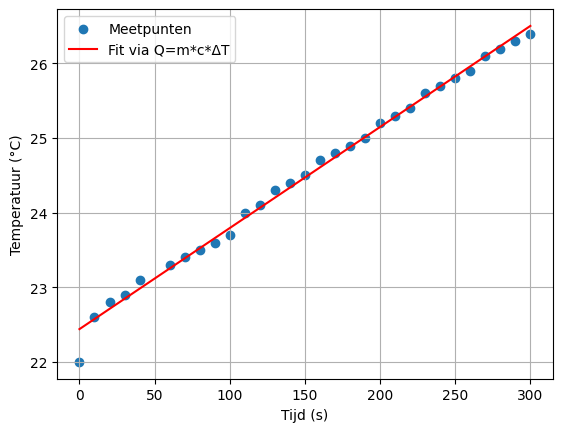

Begin temperatuur T0 = 22.44 °C
Soortelijke warmte c van het water = 4784 ± 74 J/(kg·K)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Meetdata
temperatuur = np.array([
    22, 22.6, 22.8, 22.9, 23.1, 23.3, 23.4, 23.5, 23.6, 23.7,
    24.0, 24.1, 24.3, 24.4, 24.5, 24.7, 24.8, 24.9, 25.0,
    25.2, 25.3, 25.4, 25.6, 25.7, 25.8, 25.9, 26.1, 26.2,
    26.3, 26.4
])
tijd = np.array([
    0, 10, 20, 30, 40, 60, 70, 80, 90, 100, 110, 120, 130,
    140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240,
    250, 260, 270, 280, 290, 300
])

# Gegeven vermogen en massa
P = 18*1.8  # W
m = 0.50  # kg

# Model gebaseerd op Q = m*c*ΔT
def T_model_Q(t, T0, c):
    return T0 + (P / (m * c)) * t

# Beginwaarden: T0 = eerste meetpunt, c_water ≈ 4180 J/kgK bij een druk van 1 atm
p0 = [temperatuur[0], 4180]

# Curvefit
params, cov = curve_fit(T_model_Q, tijd, temperatuur, p0=p0)
T0_fit, c_fit = params
c_err = np.sqrt(cov[1, 1])

# Plot
t_fit = np.linspace(0, 300, 400)
plt.figure()
plt.scatter(tijd, temperatuur, label="Meetpunten")
plt.plot(t_fit, T_model_Q(t_fit, *params), label="Fit via Q=m*c*ΔT", color='red')
plt.xlabel("Tijd (s)")
plt.ylabel("Temperatuur (°C)")
plt.legend()
plt.grid()
plt.show()

# Resultaten
print(f"Begin temperatuur T0 = {T0_fit:.2f} °C")
print(f"Soortelijke warmte c van het water = {c_fit:.0f} ± {c_err:.0f} J/(kg·K)")


# Discussie en conclusie
We zien uit de grafiek dat de curvefit goed overeenkomt met onze datapunten. Hieruit blijkt dat er nauwkeurig gemeten is.
